# EDA cấu trúc bảng — không deskew

Dùng cùng ảnh M2 nghiêng 2° để quan sát pipeline khi bỏ hoàn toàn bước làm thẳng ảnh.

## 1. Chuẩn bị

Nạp dữ liệu và tạo đúng ảnh nghiêng đang dùng trong notebook có deskew.

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
assert (ROOT / 'data/training_set/manifest.jsonl').is_file(), 'Không tìm thấy data/training_set; mở notebook từ thư mục Doc2Table/notebooks.'
TRAIN_DIR = ROOT / 'data' / 'training_set'

SAMPLE_ID = 'train-00300'
PAGE_INDEX = 0
DEMO_SKEW_DEGREES = 2.0

records = [json.loads(line) for line in (TRAIN_DIR / 'manifest.jsonl').read_text(encoding='utf-8').splitlines()]
record = next(row for row in records if row['id'] == SAMPLE_ID)
image_path = TRAIN_DIR / record['image_paths'][PAGE_INDEX]
label_path = TRAIN_DIR / record['page_label_paths'][PAGE_INDEX]
original_gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
assert original_gray is not None, f'Không đọc được ảnh: {image_path}'
height, width = original_gray.shape
demo_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), DEMO_SKEW_DEGREES, 1.0)
gray = cv2.warpAffine(original_gray, demo_matrix, (width, height), flags=cv2.INTER_CUBIC, borderValue=255)

print('ID:', SAMPLE_ID, '| difficulty:', record['difficulty'])
print('Ảnh:', image_path.name, '| góc nghiêng mô phỏng:', DEMO_SKEW_DEGREES, '°')

ID: train-00300 | difficulty: M2
Ảnh: train-00300_p01.jpg | góc nghiêng mô phỏng: 2.0 °


## 2. Ảnh đầu vào

Pipeline bắt đầu trực tiếp từ ảnh nghiêng; không có Canny, Hough hoặc phép xoay hiệu chỉnh.

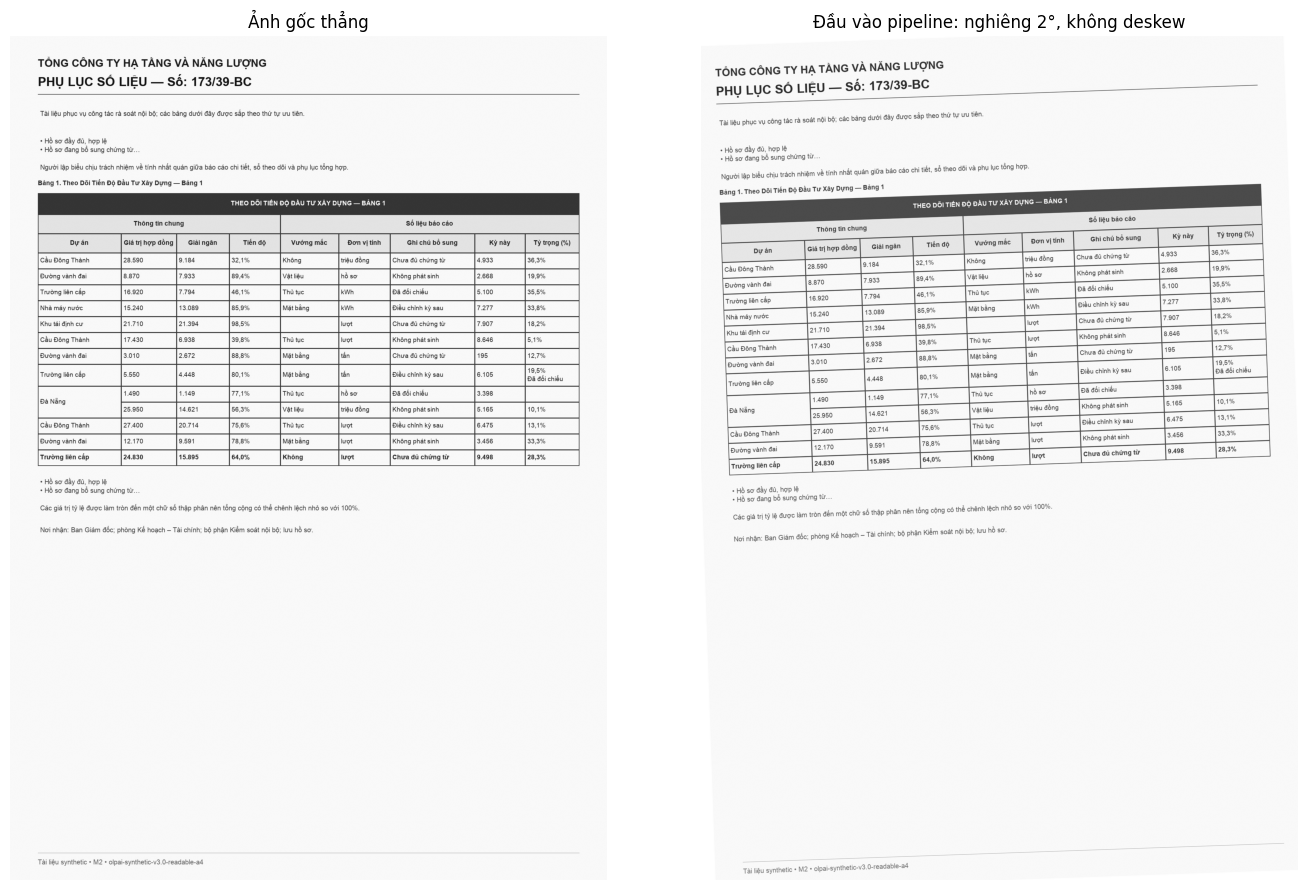

| **THEO DÕI TIẾN ĐỘ ĐẦU TƯ XÂY DỰNG — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Thông tin chung** | [[H]] | [[H]] | [[H]] | **Số liệu báo cáo** | [[H]] | [[H]] | [[H]] | [[H]] |
| **Dự án** | **Giá trị hợp đồng** | **Giải ngân** | **Tiến độ** | **Vướng mắc** | **Đơn vị tính** | **Ghi chú bổ sung** | **Kỳ này** | **Tỷ trọng (%)** |
| Cầu Đông Thành | 28.590 | 9.184 | 32,1% | Không | triệu đồng | Chưa đủ chứng từ | 4.933 | 36,3% |
| Đường vành đai | 8.870 | 7.933 | 89,4% | Vật liệu | hồ sơ | Không phát sinh | 2.668 | 19,9% |
| Trường liên cấp | 16.920 | 7.794 | 46,1% | Thủ tục | kWh | Đã đối chiếu | 5.100 | 35,5% |
| Nhà máy nước | 15.240 | 13.089 | 85,9% | Mặt bằng | kWh | Điều chỉnh kỳ sau | 7.277 | 33,8% |
| Khu tái định cư | 21.710 | 21.394 | 98,5% |  | lượt | Chưa đủ chứng từ | 7.907 | 18,2% |
| Cầu Đông Thành | 17.430 | 6.938 | 39,8% | Thủ tục | lượt | Không phát sinh | 8.646 | 5,1% |
| Đư

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
axes[0].imshow(original_gray, cmap='gray'); axes[0].set_title('Ảnh gốc thẳng')
axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Đầu vào pipeline: nghiêng 2°, không deskew')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(label_path.read_text(encoding='utf-8'))

## 3. Nhị phân hóa trực tiếp

CLAHE và Otsu được áp dụng lên ảnh nghiêng thay vì ảnh đã làm thẳng.

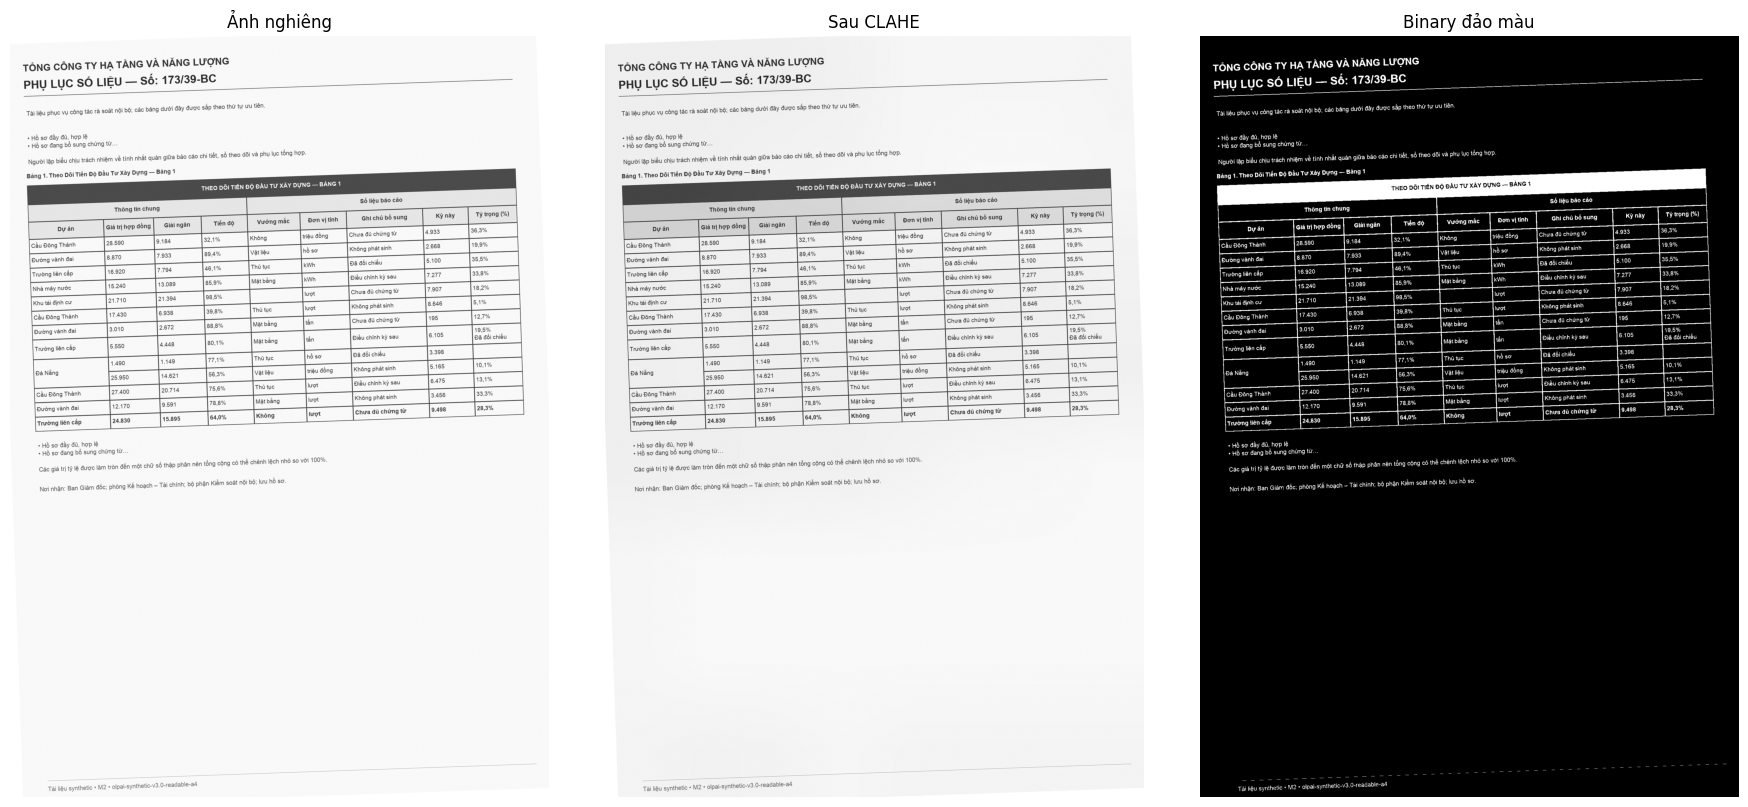

In [3]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
binary = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, image, title in zip(axes, [gray, clahe, binary], ['Ảnh nghiêng', 'Sau CLAHE', 'Binary đảo màu']):
    ax.imshow(image, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Tách đường ngang và đường dọc

Kernel vẫn song song với trục ảnh nên các đường nghiêng có thể mỏng hoặc đứt đoạn.

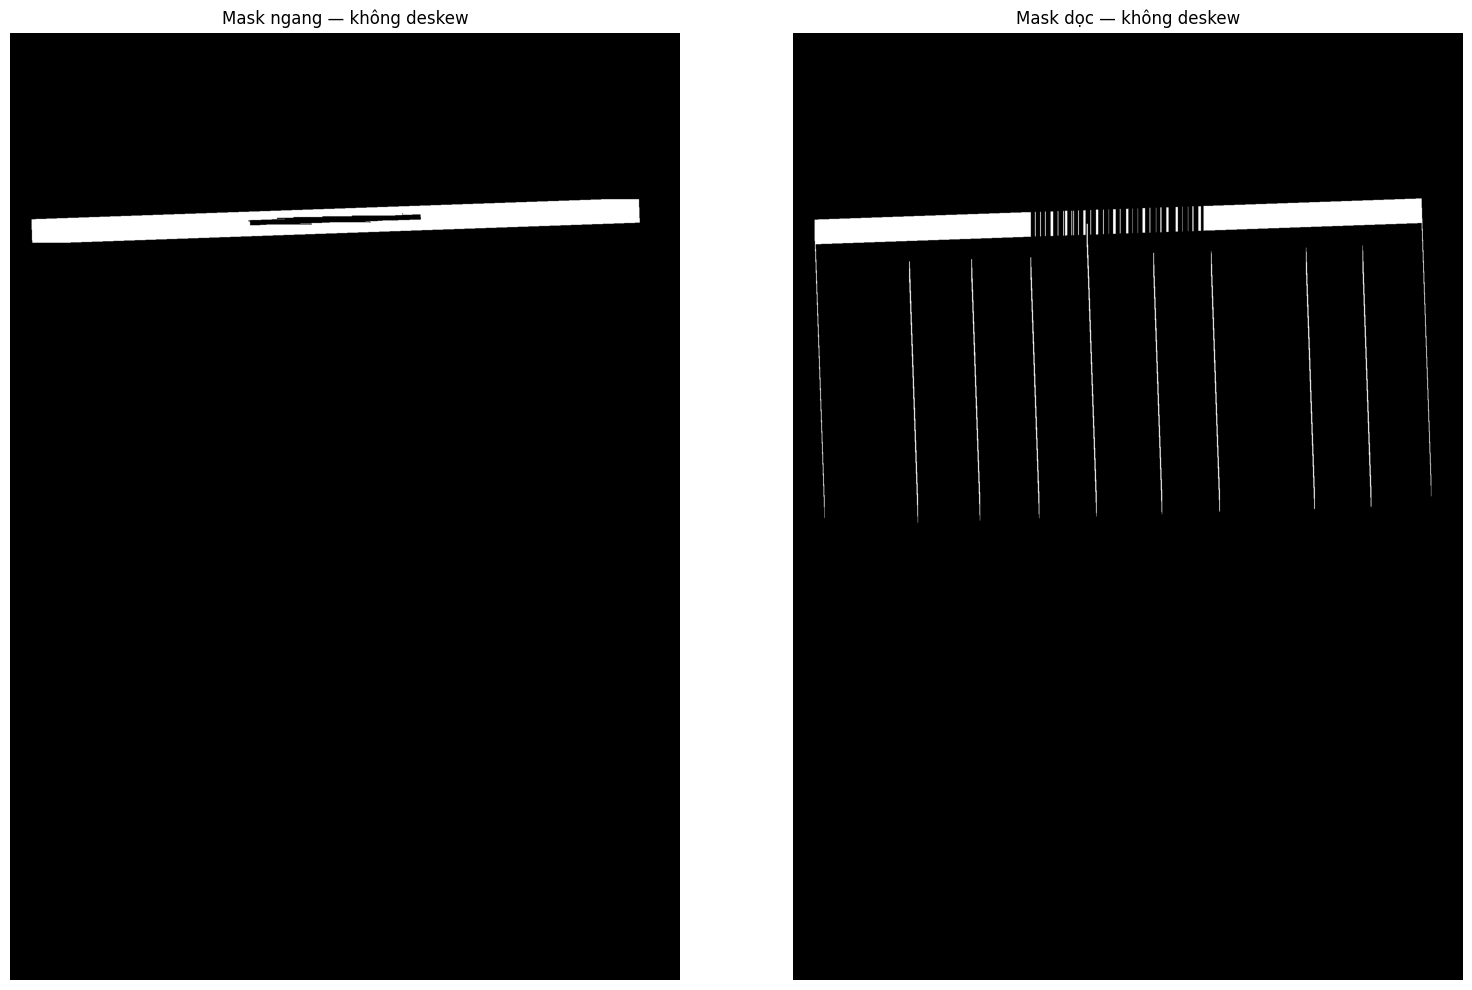

Pixel mask ngang: 100579
Pixel mask dọc  : 104224


In [4]:
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(45, width // 18), 1))
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(35, height // 45)))
horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
for ax, image, title in zip(axes, [horizontal, vertical], ['Mask ngang — không deskew', 'Mask dọc — không deskew']):
    ax.imshow(image, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.show()
print('Pixel mask ngang:', np.count_nonzero(horizontal))
print('Pixel mask dọc  :', np.count_nonzero(vertical))

## 5. Ghép mask và tìm vùng bảng

Contour cho thấy các nét còn lại có đủ nối thành một vùng bảng hoàn chỉnh hay không.

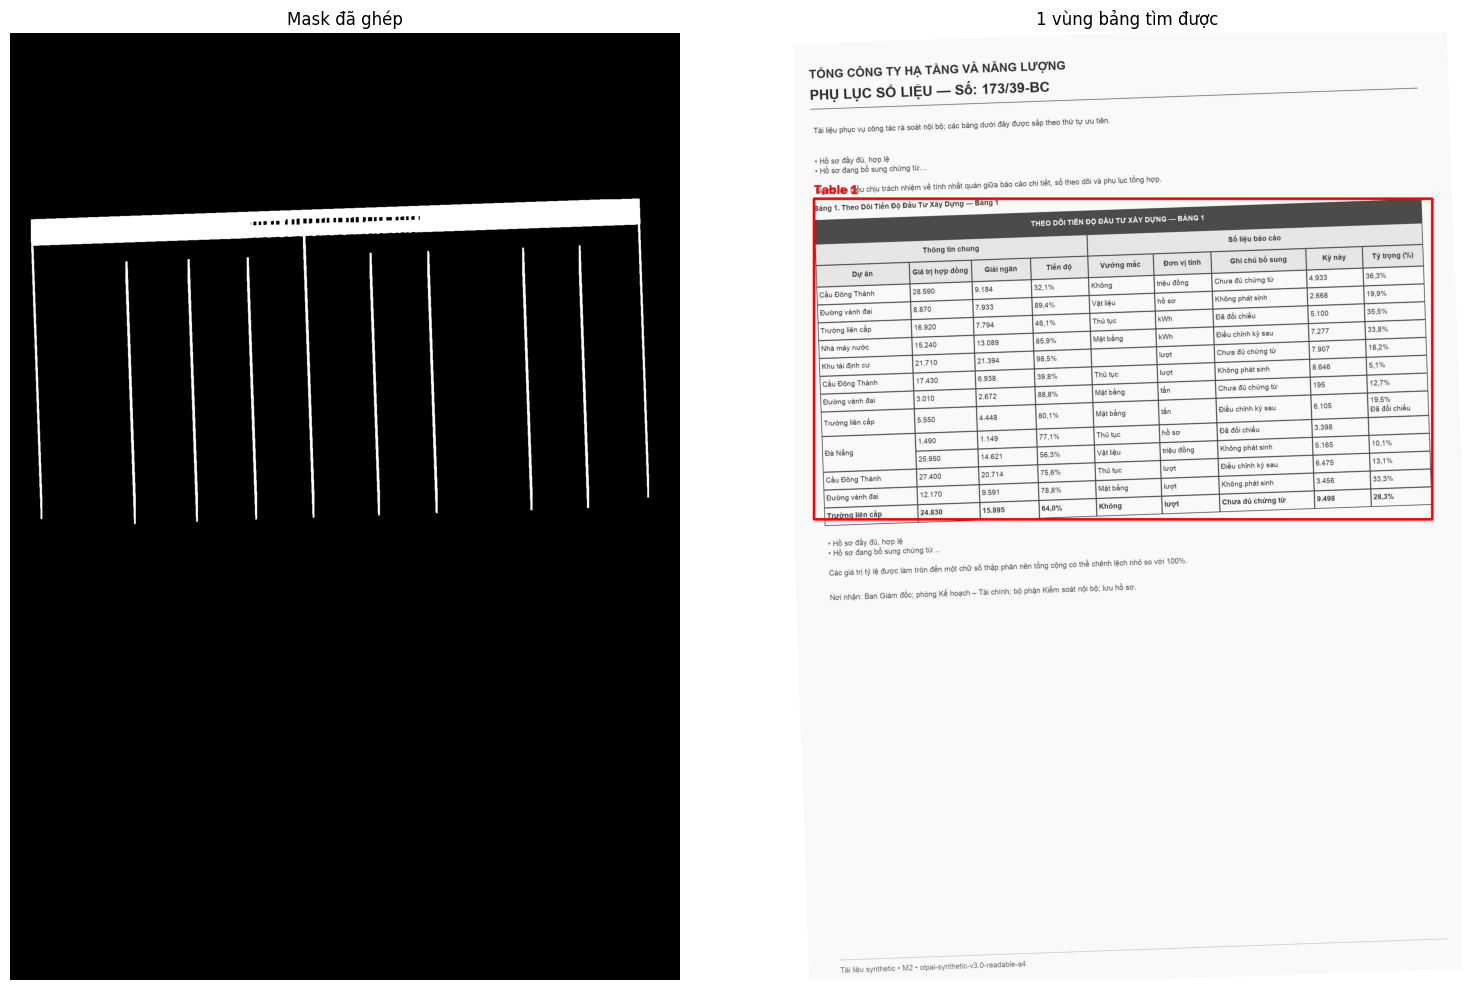

Bounding boxes: [(56, 445, 1717, 1307)]


In [5]:
joined = cv2.dilate(cv2.bitwise_or(horizontal, vertical), cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)), iterations=1)
contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if w >= width * 0.48 and h >= 80 and w * h >= width * height * 0.012:
        boxes.append((x, y, x + w, y + h))
boxes.sort(key=lambda box: (box[1], box[0]))

overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
for index, (x0, y0, x1, y1) in enumerate(boxes, 1):
    cv2.rectangle(overlay, (x0, y0), (x1, y1), (255, 0, 0), 5)
    cv2.putText(overlay, f'Table {index}', (x0, max(30, y0 - 12)), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].imshow(joined, cmap='gray'); axes[0].set_title('Mask đã ghép')
axes[1].imshow(overlay); axes[1].set_title(f'{len(boxes)} vùng bảng tìm được')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Bounding boxes:', boxes)

## 6. Tìm `x_edges` và `y_edges`

Nếu còn vùng bảng, projection cho thấy đường nghiêng không tập trung tại một tọa độ x/y cố định.

x_edges: []
y_edges: [507]
Số hàng/cột suy ra: 0 × 0


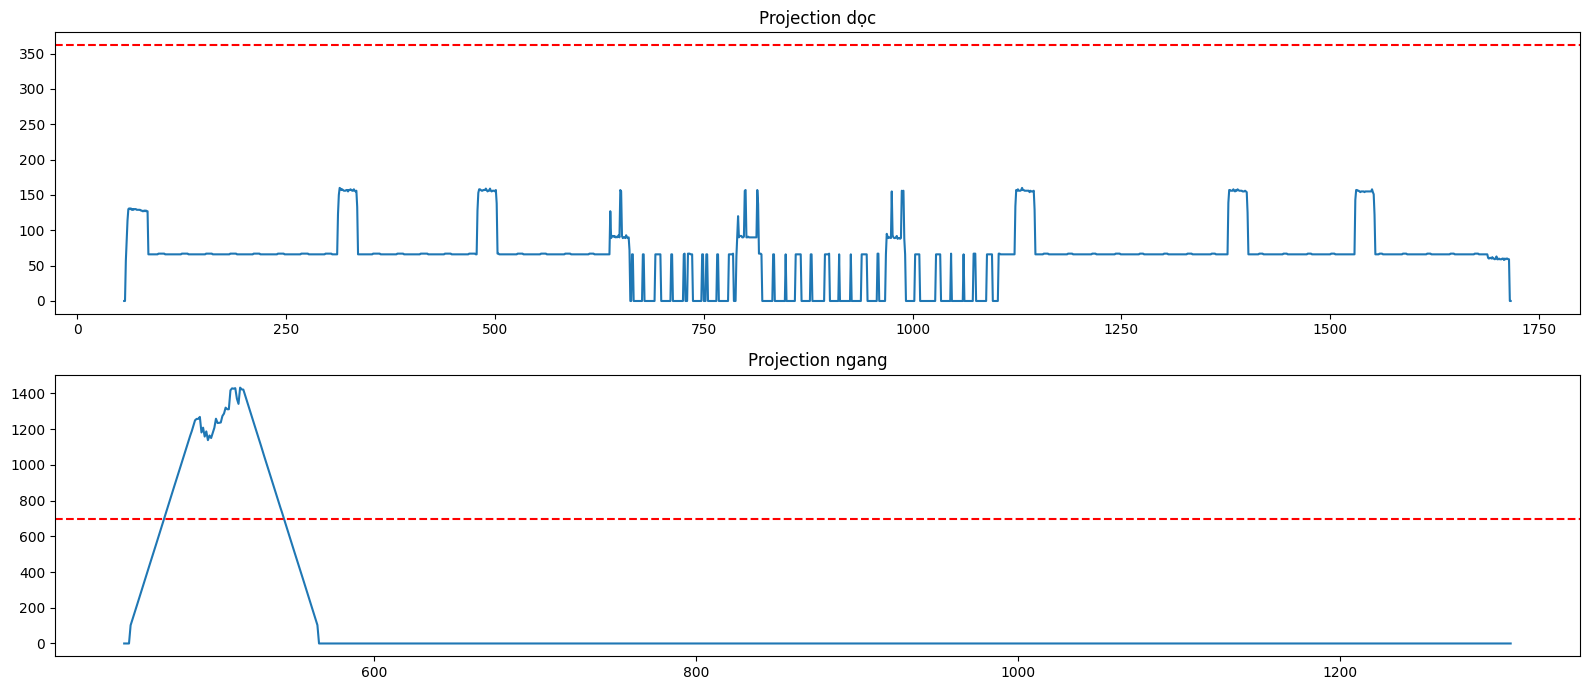

In [6]:
def runs(mask, gap=3):
    indices = np.flatnonzero(mask)
    if not len(indices): return []
    groups, start, previous = [], int(indices[0]), int(indices[0])
    for value in map(int, indices[1:]):
        if value - previous > gap:
            groups.append((start, previous)); start = value
        previous = value
    return groups + [(start, previous)]

def line_positions(mask, axis, extent):
    projection = np.count_nonzero(mask, axis=axis)
    threshold = max(8, round(extent * 0.42))
    positions = [round((start + end) / 2) for start, end in runs(projection >= threshold)]
    return positions, projection, threshold

if boxes:
    x0, y0, x1, y1 = boxes[0]
    xs, vertical_projection, x_threshold = line_positions(vertical[y0:y1, x0:x1], axis=0, extent=y1-y0)
    ys, horizontal_projection, y_threshold = line_positions(horizontal[y0:y1, x0:x1], axis=1, extent=x1-x0)
    x_edges = [x0 + value for value in xs]
    y_edges = [y0 + value for value in ys]
else:
    x_edges, y_edges = [], []

print('x_edges:', x_edges)
print('y_edges:', y_edges)
print('Số hàng/cột suy ra:', max(0, len(y_edges)-1), '×', max(0, len(x_edges)-1))

if boxes:
    fig, axes = plt.subplots(2, 1, figsize=(16, 7))
    axes[0].plot(np.arange(x0, x1), vertical_projection); axes[0].axhline(x_threshold, color='red', linestyle='--')
    axes[0].set_title('Projection dọc')
    axes[1].plot(np.arange(y0, y1), horizontal_projection); axes[1].axhline(y_threshold, color='red', linestyle='--')
    axes[1].set_title('Projection ngang')
    plt.tight_layout(); plt.show()

## 7. Vẽ lưới và crop ô

Nếu tìm được đủ biên, hình này cho thấy crop song song trục ảnh lệch khỏi cell nghiêng ra sao.

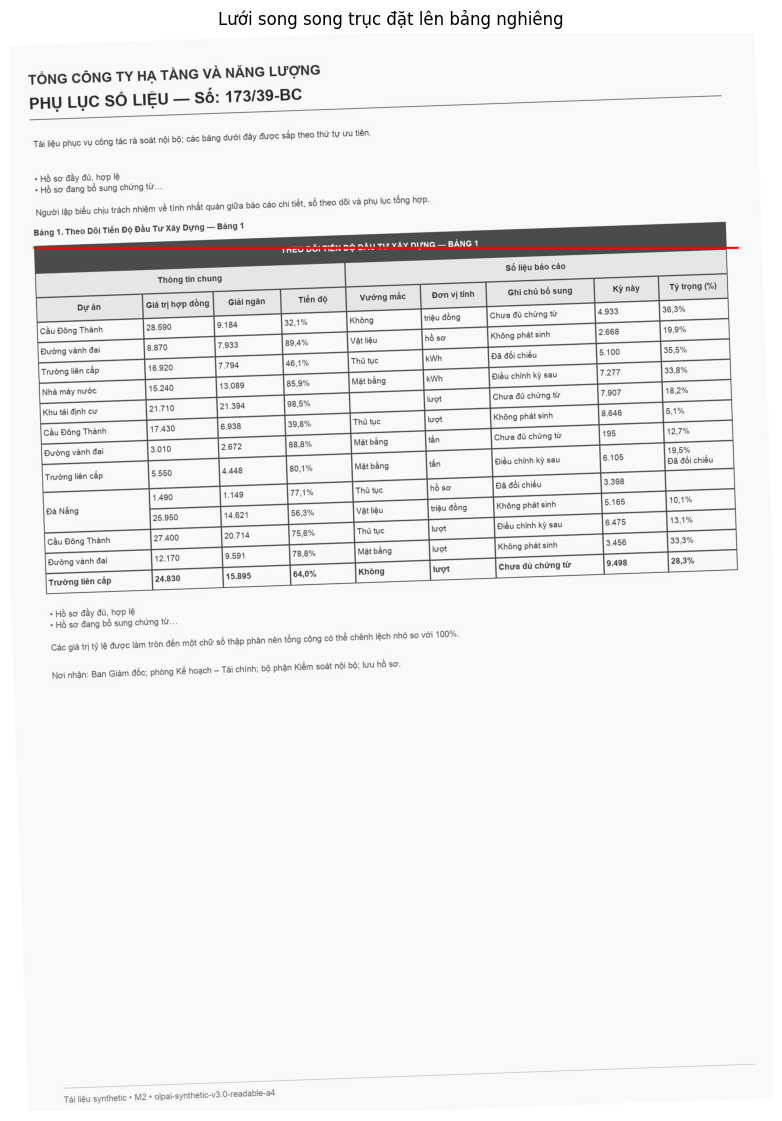

Không có crop vì pipeline không tìm được đủ biên.


In [7]:
grid_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
if boxes:
    for x in x_edges: cv2.line(grid_overlay, (x, y0), (x, y1), (0, 180, 0), 4)
    for y in y_edges: cv2.line(grid_overlay, (x0, y), (x1, y), (255, 0, 0), 4)

plt.figure(figsize=(12, 14))
plt.imshow(grid_overlay)
plt.title('Lưới song song trục đặt lên bảng nghiêng')
plt.axis('off'); plt.show()

cell_crops = []
for row in range(max(0, len(y_edges)-1)):
    for col in range(max(0, len(x_edges)-1)):
        left, right = x_edges[col]+2, x_edges[col+1]-2
        top, bottom = y_edges[row]+2, y_edges[row+1]-2
        cell_crops.append((row, col, gray[top:bottom, left:right]))

shown = cell_crops[:min(24, len(cell_crops))]
if shown:
    columns = min(4, len(shown)); rows = int(np.ceil(len(shown)/columns))
    fig, axes = plt.subplots(rows, columns, figsize=(16, 3*rows), squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for ax, (row, col, crop) in zip(axes.ravel(), shown):
        ax.imshow(crop, cmap='gray'); ax.set_title(f'ô ({row}, {col})')
    plt.tight_layout(); plt.show()
else:
    print('Không có crop vì pipeline không tìm được đủ biên.')

## 8. So sánh

Chạy notebook này cạnh `EDA_table_structure.ipynb`: cùng ảnh và góc 2°, khác duy nhất việc ảnh có được deskew trước morphology hay không.